# 04. Fine-Grained Sub-Nuclear Localization Transfer

## Overview
Having established that 2-Hidden-Layer MLPs trained on ESM-2 embeddings achieve our best accuracy on 11-compartment whole-cell localization, we now investigate whether these representations transfer to **fine-grained intra-nuclear sub-compartments**.

### Target Nuclear Sub-Compartments (Human Protein Atlas):
1. **Nucleoplasm**
2. **Nucleoli**
3. **Nuclear Bodies**
4. **Nuclear speckles**
5. **Nuclear membrane**
6. **Fibrillar center**
7. **Other**

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import protein_loc as pl

%matplotlib inline
pl.set_seed(42)

## 1. Load Sub-Nuclear Dataset

In [2]:
nuc_df, X_nuc, y_nuc = pl.load_nuclear_data('../data/df_Atlass_nuclear_localizations_mean_pooling.csv')

print(f"Loaded sub-nuclear dataset: {X_nuc.shape[0]:,} proteins across {len(pl.NUCLEAR_LOCATIONS)} sub-compartments.")

Loaded sub-nuclear dataset: 12,979 proteins across 7 sub-compartments.


## 2. Nuclear Sub-Compartment Distribution

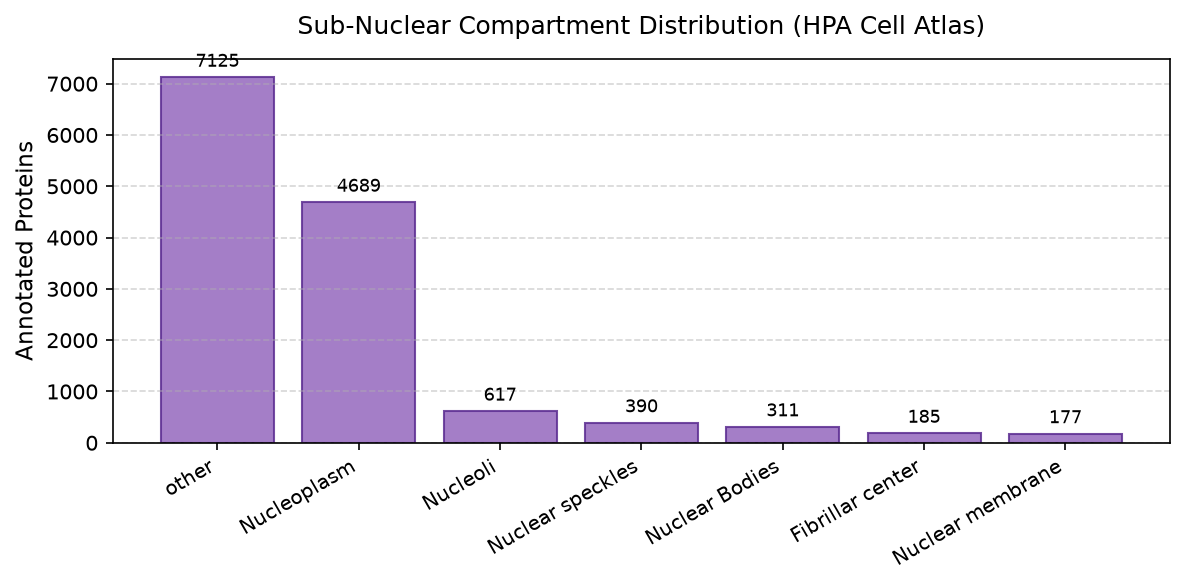

In [3]:
counts_nuc = pd.Series(y_nuc.sum(axis=0), index=pl.NUCLEAR_LOCATIONS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
bars = ax.bar(counts_nuc.index, counts_nuc.values, color='#9467bd', edgecolor='#5c2d91', alpha=0.85)
ax.set_ylabel('Annotated Proteins', fontsize=11)
ax.set_title('Sub-Nuclear Compartment Distribution (HPA Cell Atlas)', fontsize=12, pad=12)
plt.xticks(rotation=30, ha='right', fontsize=9.5)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

Again, we see that the sub-nuclear compartment distribution is extremely unbalanced.

## 3. Train & Evaluate Transferred 2-Hidden MLP Architecture

We train the $1280 \to 128 \to 64 \to 7$ MLP on 80% of the nuclear proteins and evaluate on the held-out 20% test set.

findfont: Failed to find font weight medium, now using 400.


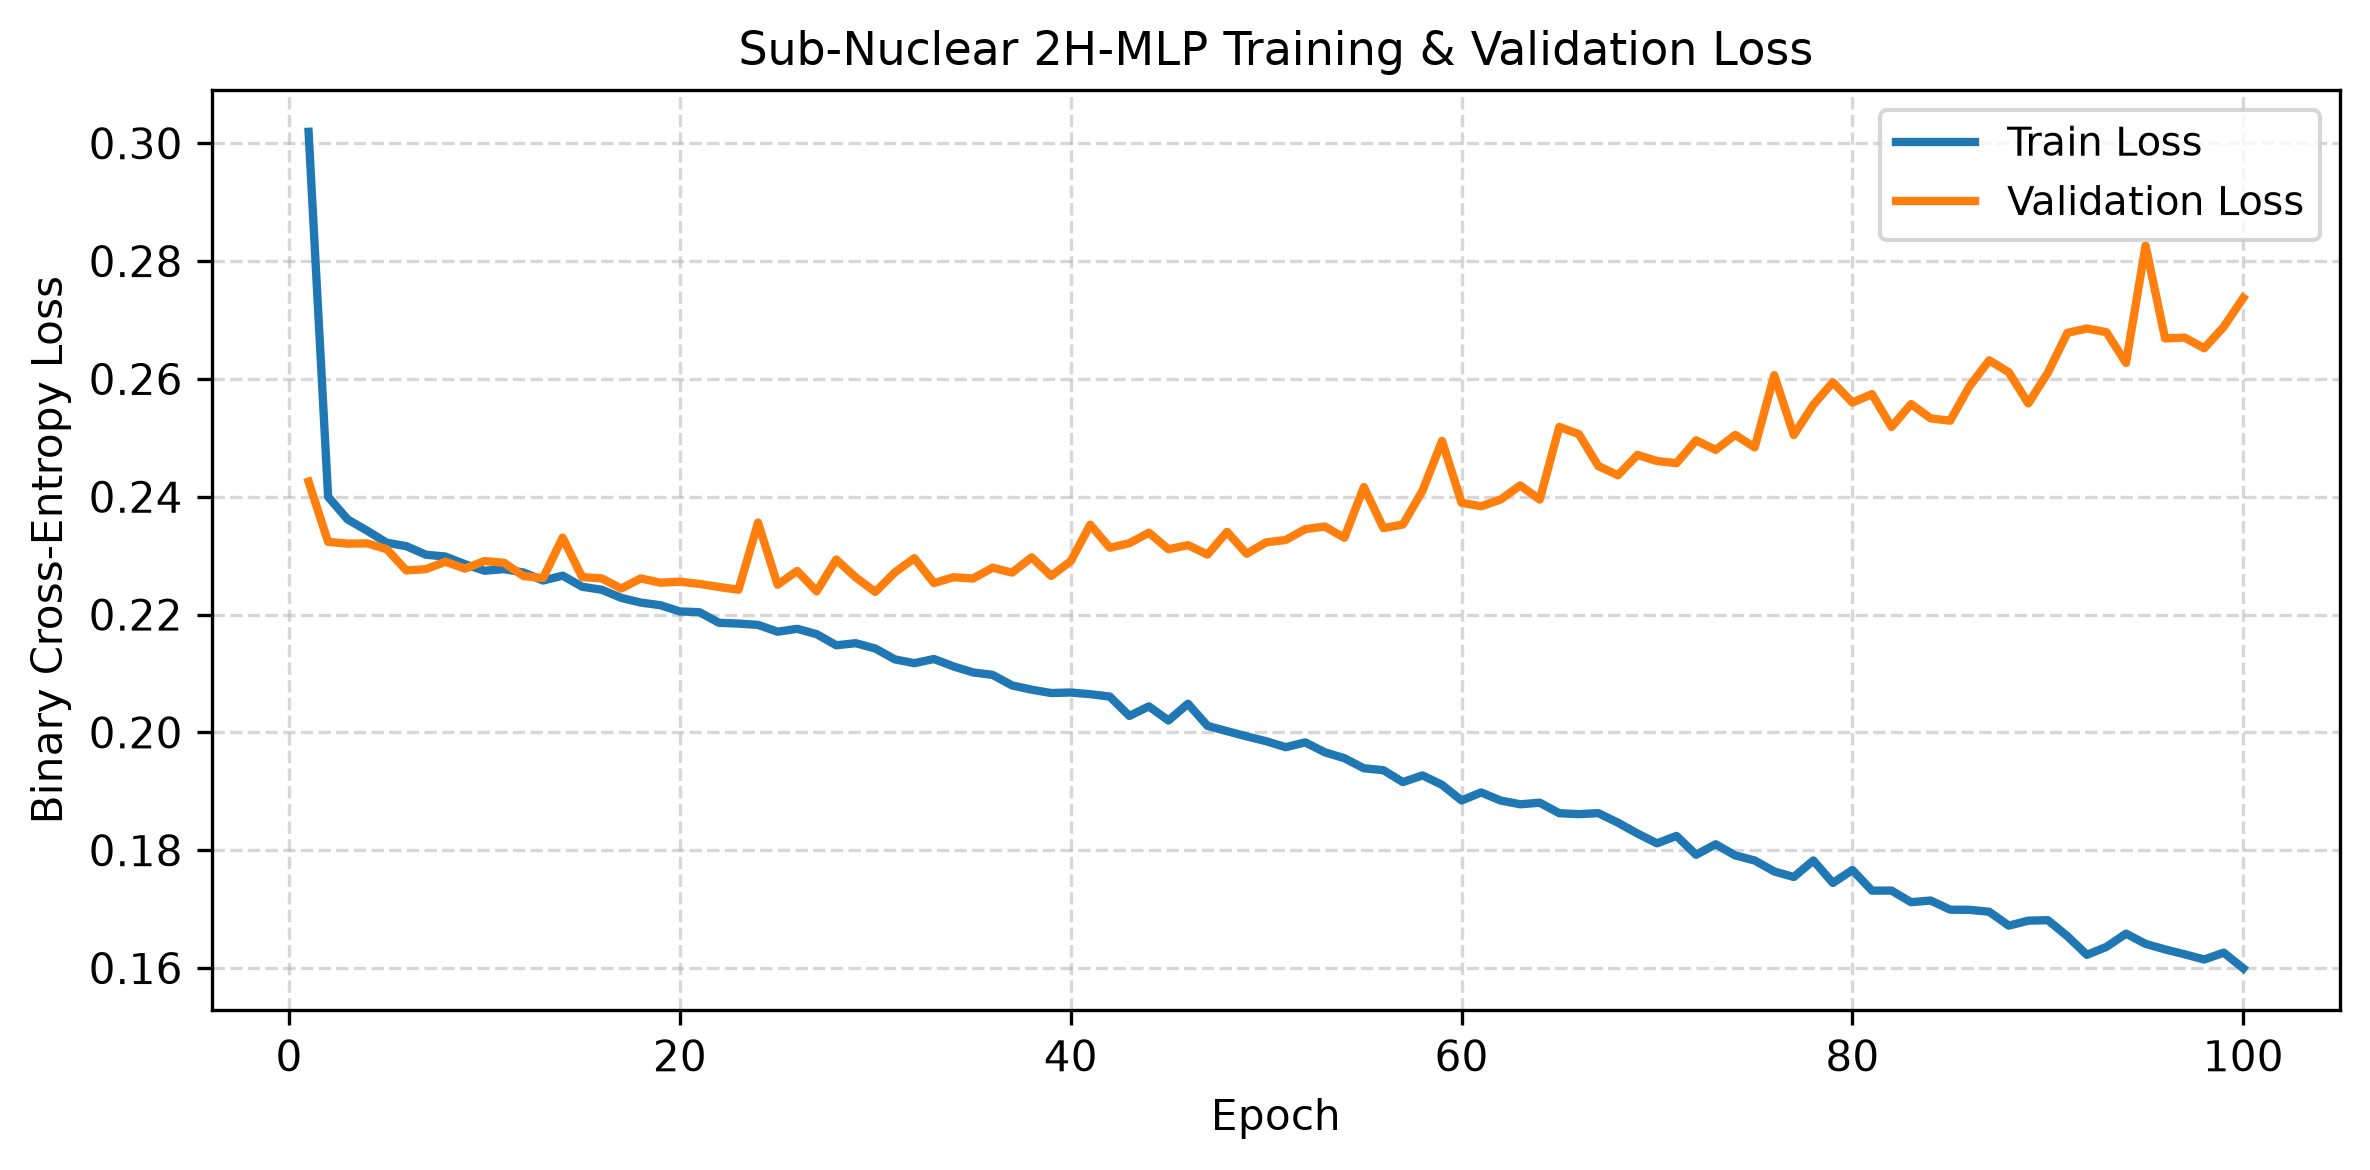

,Metric,Value
0,Exact-match Accuracy,0.3309
1,Hamming Accuracy,0.7842
2,Jaccard Index (Samples),0.4687
3,Micro F1,0.4730
4,Macro F1,0.2819
5,Mean per-class MCC,0.1954


In [4]:
nuc_results = pl.run_nuclear_experiment(
    df=nuc_df,
    model_factory=lambda: pl.get_model('mlp_2h', input_dim=1280, num_classes=7),
    test_size=0.2,
    epochs=100,
    lr=1e-3,
    regularizer=pl.ridge_penalty(1e-4),
    seed=42,
)

# Plot training vs validation loss curve
fig, ax = pl.plot_training_curves(
    nuc_results['history'],
    title='Sub-Nuclear 2H-MLP Training & Validation Loss',
    save_path='../figures/nuclear_loss_curve.pdf'
)
plt.show()

# Format and display overall metrics
metrics_df = pl.format_metrics_table(nuc_results['metrics'])
metrics_df

## 4. Per-Compartment Sub-Nuclear MCC Analysis

In [7]:
pc_df = pl.format_per_class_table(nuc_results['metrics'])
pc_df

,Location,Accuracy,MCC,Precision,Recall,F1,Positives
0,Nucleoplasm,0.7053,0.3726,0.5797,0.6354,0.6063,927
1,Nucleoli,0.9619,0.3310,0.4630,0.2632,0.3356,95
2,Nuclear Bodies,0.8240,0.0398,0.0401,0.2537,0.0692,67
3,Nuclear speckles,0.9715,0.1537,0.3000,0.0909,0.1395,66
4,Nuclear membrane,0.8648,0.0188,0.0215,0.1750,0.0384,40
5,Fibrillar center,0.4495,0.0368,0.0207,0.6977,0.0403,43
6,other,0.7122,0.4155,0.7438,0.7443,0.7441,1459
